<a href="https://colab.research.google.com/github/Akash14-09/Machine_Learning/blob/main/Project1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:


!pip -q install transformers torch pillow gradio pandas gtts

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 668.2/668.2 kB 43.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
wandb 0.28.0 requires click>=8.2.0, but you have click 8.1.8 which is incompatible.


In [4]:
from transformers import BlipProcessor, BlipForConditionalGeneration
from PIL import Image
from google.colab import files
import pandas as pd
from gtts import gTTS
from IPython.display import Audio, display

processor=BlipProcessor.from_pretrained('Salesforce/blip-image-captioning-base')
model=BlipForConditionalGeneration.from_pretrained('Salesforce/blip-image-captioning-base')
print('Model loaded')


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.56k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

Model loaded


Saving gettyimages-2159210075-612x612.jpg to gettyimages-2159210075-612x612.jpg


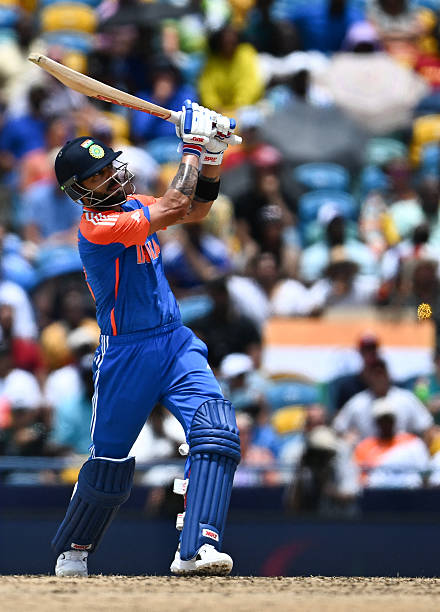

In [7]:
uploaded=files.upload()
image_path=list(uploaded.keys())[0]
image=Image.open(image_path).convert('RGB')
display(image)

In [8]:
inputs=processor(images=image,return_tensors='pt')
out=model.generate(**inputs,output_scores=True,return_dict_in_generate=True)
caption=processor.decode(out.sequences[0],skip_special_tokens=True)
import torch
probs=[]
for s in out.scores:
    probs.append(torch.max(torch.softmax(s,dim=-1)).item())
confidence=sum(probs)/len(probs)*100 if probs else 100
print('Caption:',caption)
print(f'Estimated Confidence: {confidence:.2f}%')

Caption: a man in a blue uniform swinging a bat
Estimated Confidence: 43.99%


In [9]:
tts=gTTS(caption)
tts.save('caption.mp3')
display(Audio('caption.mp3',autoplay=False))

df=pd.DataFrame([{'Image':image_path,'Caption':caption,'Estimated Confidence':round(confidence,2)}])
df.to_csv('caption_history.csv',index=False)
print(df)
print('Saved caption_history.csv')

                                Image                                 Caption  \
0  gettyimages-2159210075-612x612.jpg  a man in a blue uniform swinging a bat   

   Estimated Confidence  
0                 43.99  
Saved caption_history.csv
